# Kelompok 18 - Data Mining Dan Visualisasi (C)
#### Akbar Razan (5003221150)
#### Fadhil Rahman Saputra (5003231174)
#### Khairunnisa Cahya Nagari (5003231186)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold, KFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load dataset
df = pd.read_csv('mushrooms.csv')

print("=== DATASET MUSHROOMS ===")
print(f"Shape: {df.shape}")
print(f"Features: {len(df.columns)-1}")
print(f"Samples: {len(df)}")
print(f"\nClass Distribution:")
print(df['class'].value_counts())
print(f"Edible: {df['class'].value_counts().get('e', 0)} ({df['class'].value_counts().get('e', 0)/len(df)*100:.1f}%)")
print(f"Poisonous: {df['class'].value_counts().get('p', 0)} ({df['class'].value_counts().get('p', 0)/len(df)*100:.1f}%")

=== DATASET MUSHROOMS ===
Shape: (8124, 23)
Features: 22
Samples: 8124

Class Distribution:
class
e    4208
p    3916
Name: count, dtype: int64
Edible: 4208 (51.8%)
Poisonous: 3916 (48.2%


In [ ]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

#DATA PREPROCESSING

DUPLICATED DATA

In [ ]:
df.duplicated().sum()

np.int64(0)

MISSING VALUE

In [ ]:
df.isnull().sum()/df.shape[0]*100

,0
class,0.0
cap-shape,0.0
cap-surface,0.0
cap-color,0.0
bruises,0.0
odor,0.0
gill-attachment,0.0
gill-spacing,0.0
gill-size,0.0
gill-color,0.0


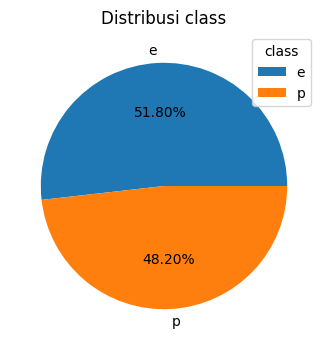

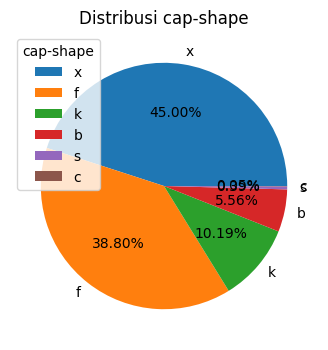

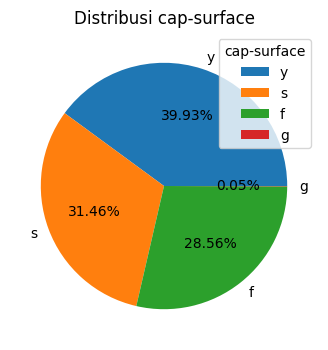

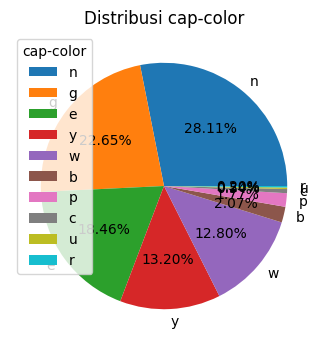

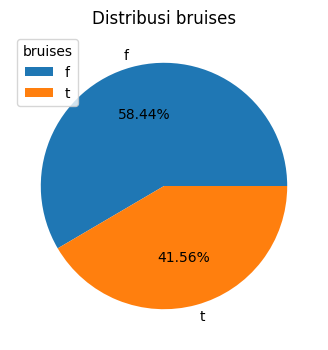

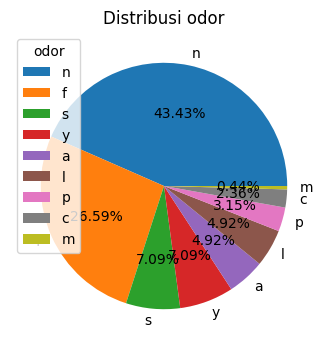

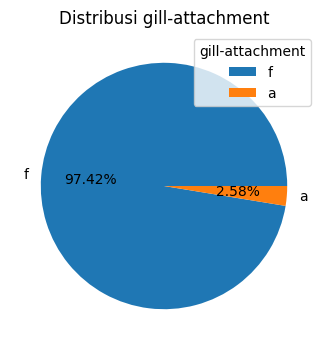

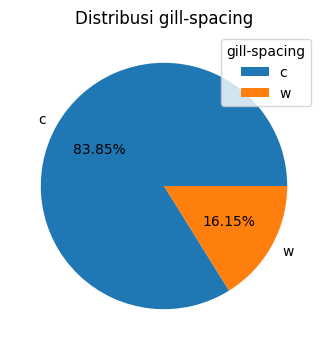

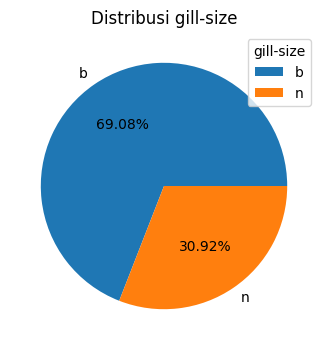

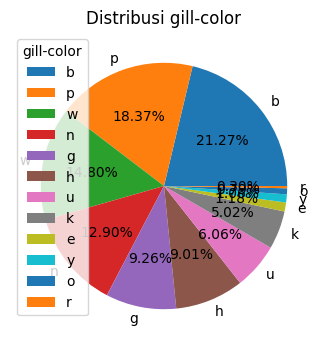

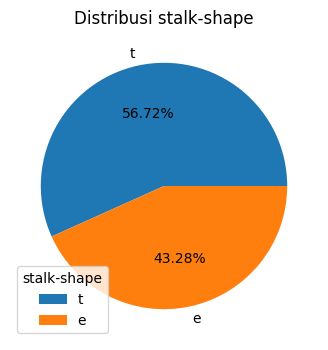

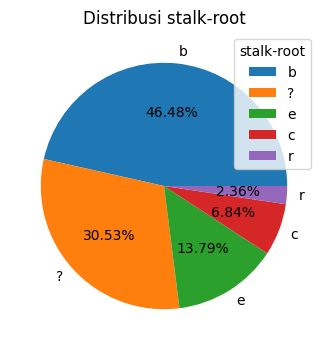

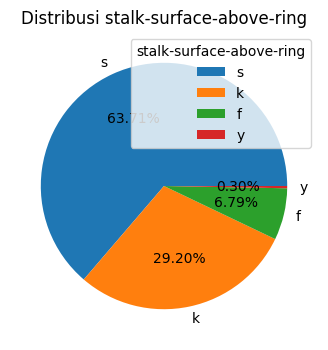

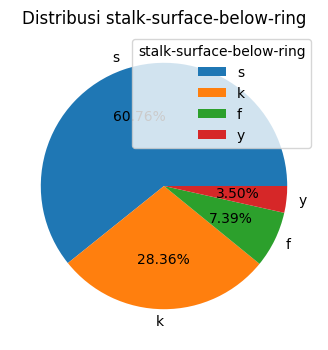

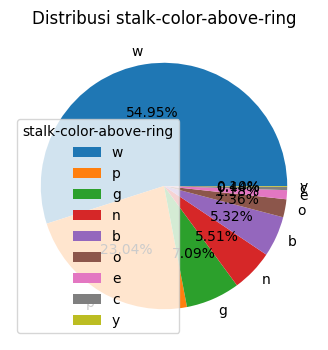

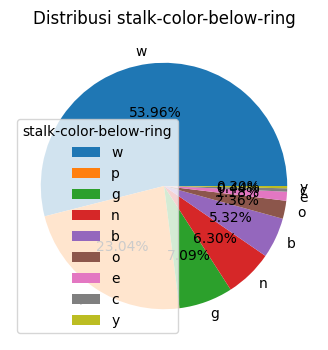

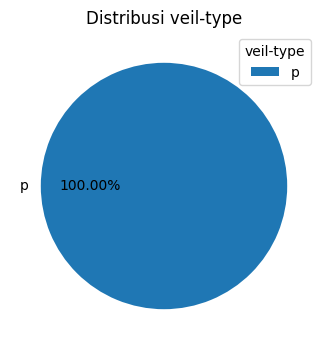

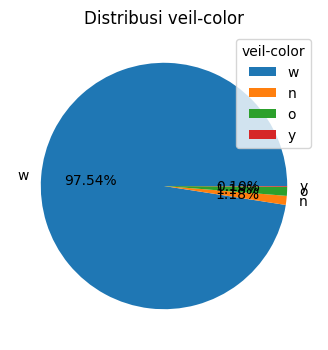

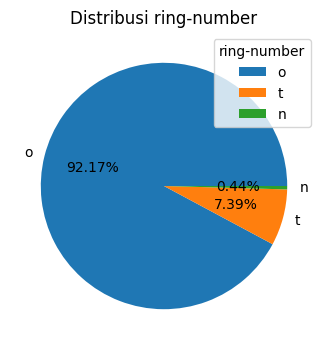

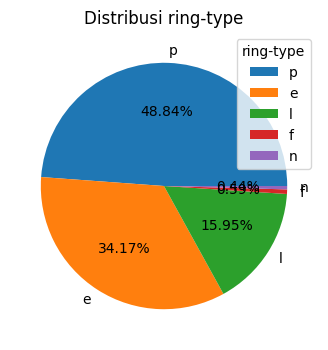

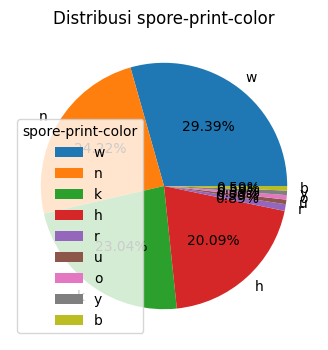

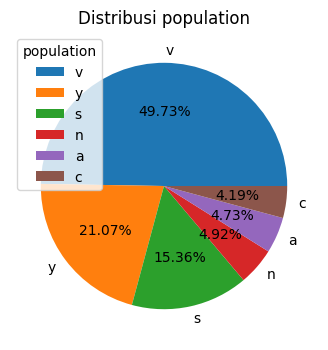

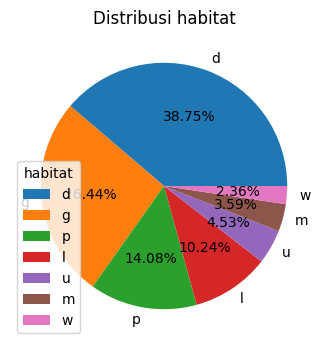

In [ ]:
# Pilih semua kolom kategorikal
categorical_cols = df.select_dtypes(include=['object']).columns

# Membuat pie chart untuk setiap kolom kategorikal
for col in categorical_cols:
    plt.figure(figsize=(4, 4))  # Menyesuaikan ukuran plot
    plt.pie(df[col].value_counts().values, labels=df[col].value_counts().index, autopct='%0.02f%%')
    plt.title(f'Distribusi {col}')
    plt.legend(df[col].value_counts().index, title=col, loc='best')
    plt.show()

FEATURE SELECTION

In [ ]:
# One-Hot Encoding
def one_hot_encoding(df):
    """One-hot encoding untuk semua fitur kategorikal"""
    df_encoded = pd.get_dummies(df, drop_first=True)
    return df_encoded

In [ ]:
# One-Hot Encoding
df_onehot = one_hot_encoding(df)
X_onehot = df_onehot.drop('class_p', axis=1)
y_onehot = df_onehot['class_p']

In [ ]:
print(f"\nShape after encoding:")
print(f"One-Hot Encoding: {X_onehot.shape}")


Shape after encoding:
One-Hot Encoding: (8124, 95)


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
# --- RFE (Recursive Feature Elimination) ---
model = LogisticRegression(max_iter=2000, random_state=42)

# Menggunakan RFE untuk memilih fitur terbaik
rfe_logreg = RFE(estimator=model, n_features_to_select=10)  # Pilih 10 fitur terbaik
rfe_logreg.fit(X_onehot, y_onehot)  # Fit model

# Menampilkan fitur yang terpilih
selected_features_logreg = X_onehot.columns[rfe_logreg.support_]
print("Fitur terpilih dengan RFE: ", selected_features_logreg)

Fitur terpilih dengan RFE:  Index(['odor_c', 'odor_f', 'odor_n', 'odor_p', 'gill-size_n',
       'stalk-color-below-ring_y', 'spore-print-color_k',
       'spore-print-color_n', 'spore-print-color_r', 'spore-print-color_u'],
      dtype='object')


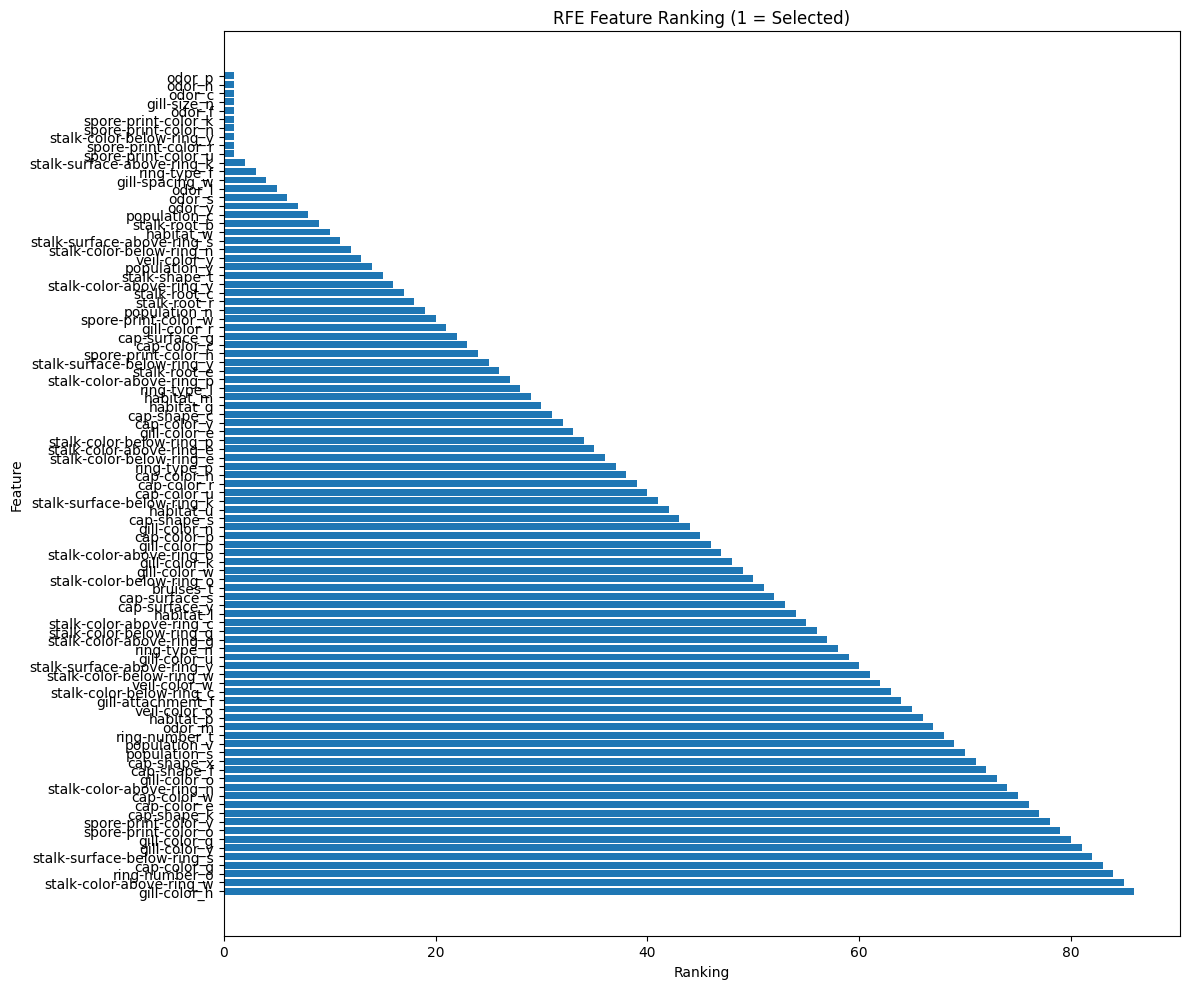

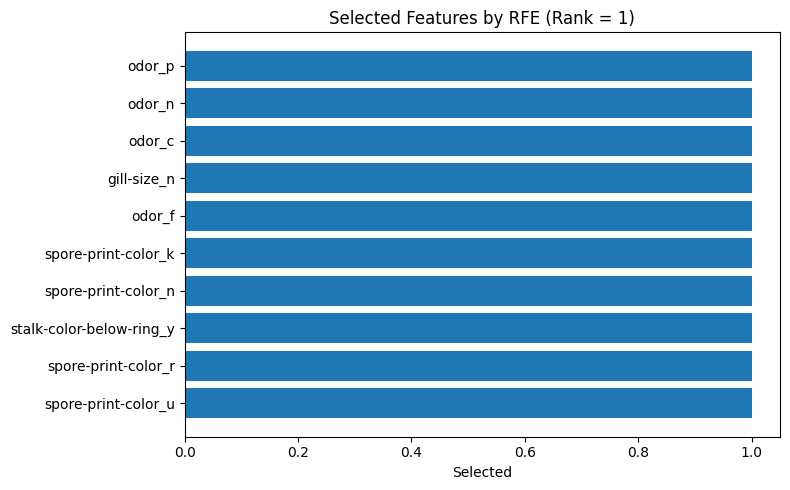

In [ ]:
# --- MEMBUAT DATAFRAME UNTUK VISUALISASI ---
rfe_results = pd.DataFrame({
    "feature": X_onehot.columns,
    "rank": rfe_logreg.ranking_,
    "selected": rfe_logreg.support_
})

# Sort ranking: fitur terbaik (rank 1) di atas
rfe_results = rfe_results.sort_values("rank")

# --- VISUALISASI: RANKING SEMUA FITUR ---
plt.figure(figsize=(12, 10))
plt.barh(rfe_results["feature"], rfe_results["rank"])
plt.gca().invert_yaxis()
plt.title("RFE Feature Ranking (1 = Selected)")
plt.xlabel("Ranking")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# --- VISUALISASI: FITUR TERPILIH SAJA ---
selected = rfe_results[rfe_results["selected"]]

plt.figure(figsize=(8, 5))
plt.barh(selected["feature"], [1]*len(selected))
plt.gca().invert_yaxis()
plt.title("Selected Features by RFE (Rank = 1)")
plt.xlabel("Selected")
plt.tight_layout()
plt.show()

# **ANALISIS CLASSIFICATION**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_onehot) # Scale X_onehot

# Memilih fitur yang terpilih oleh RFE
X_rfe_logreg = X_scaled[:, rfe_logreg.support_]  # Mengambil hanya fitur yang terpilih oleh RFE

# Step 4: Pembagian data menjadi training dan testing (Holdout)
X_train, X_test, y_train, y_test = train_test_split(X_rfe_logreg, y_onehot, test_size=0.3, random_state=42)

# Memastikan data terbagi dengan baik
print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 5686
Jumlah data testing: 2438


In [ ]:
# Step 4: Scaling data (setelah seleksi fitur)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Scaling data training setelah seleksi fitur
X_test_scaled = scaler.transform(X_test)        # Scaling data testing setelah seleksi fitur


REPEATED HOLDOUT EVALUATION

Evaluating K-Nearest Neighbors
Training Accuracy: 0.9974
Testing Accuracy: 0.9963
Sensitivity (Recall for Poisonous): 0.9924

Classification Report (Test Set):
              precision    recall  f1-score   support

      Edible       0.99      1.00      1.00      1257
   Poisonous       1.00      0.99      1.00      1181

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



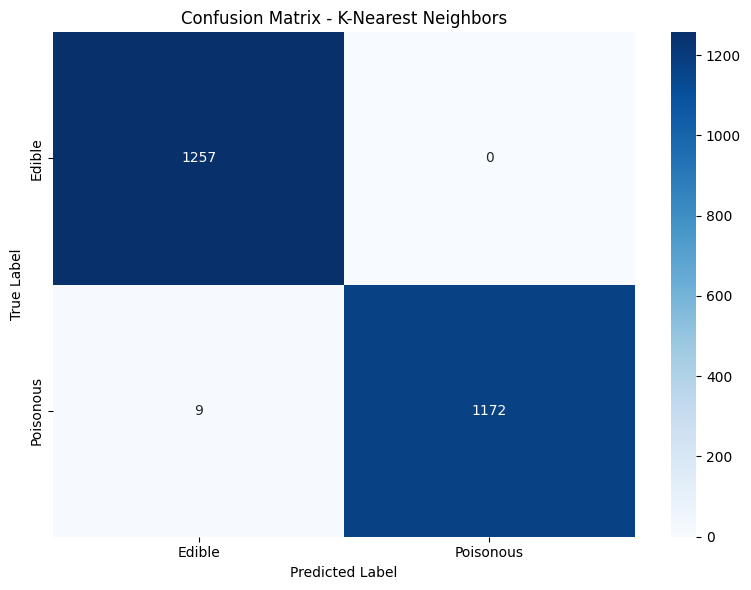


Evaluating Random Forest Classifier
Training Accuracy: 0.9974
Testing Accuracy: 0.9963
Sensitivity (Recall for Poisonous): 0.9924

Classification Report (Test Set):
              precision    recall  f1-score   support

      Edible       0.99      1.00      1.00      1257
   Poisonous       1.00      0.99      1.00      1181

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



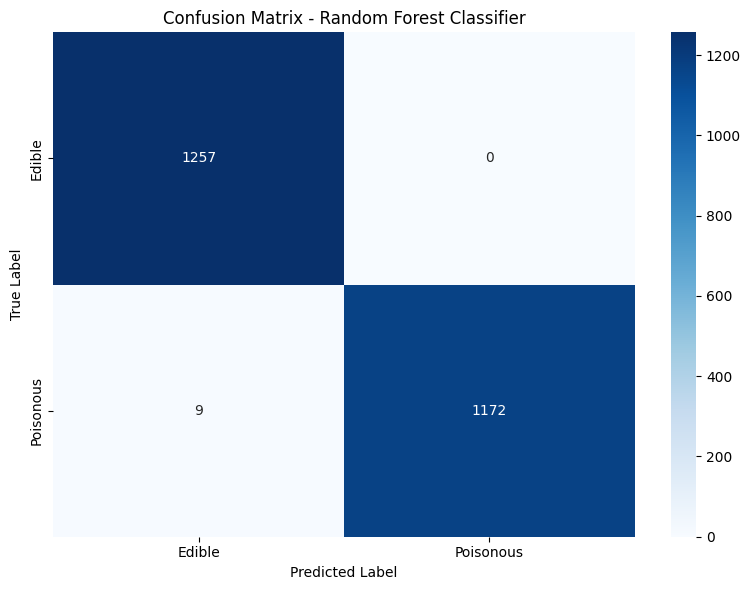

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Import model classes
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier # Added for subtask
from sklearn.ensemble import RandomForestClassifier # Added for subtask
from sklearn.metrics import roc_curve, auc # Added for ROC/AUC

# Function untuk evaluasi model
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Evaluasi model dan tampilkan hasil"""
    print(f"\n{'='*60}")
    print(f"Evaluating {model_name}")
    print('='*60)

    # Training model
    model.fit(X_train, y_train)

    # Prediksi
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Hitung akurasi
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    # Hitung sensitivitas (recall for positive class, assuming '1' is 'Poisonous')
    report = classification_report(y_test, y_pred_test, target_names=['Edible', 'Poisonous'], output_dict=True)
    sensitivity = report['Poisonous']['recall']

    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    print(f"Sensitivity (Recall for Poisonous): {sensitivity:.4f}")

    # Classification report
    print(f"\nClassification Report (Test Set):")
    print(classification_report(y_test, y_pred_test,
                                target_names=['Edible', 'Poisonous']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Edible', 'Poisonous'],
                yticklabels=['Edible', 'Poisonous'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return test_acc, sensitivity

# Inisialisasi model - SVC needs probability=True for ROC/AUC
svc_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
knn_model = KNeighborsClassifier(n_neighbors=5)
dt_model = DecisionTreeClassifier(random_state=42) # Initialized for subtask
rf_model = RandomForestClassifier(random_state=42) # Initialized for subtask - Removed probability=True

# Evaluasi model dengan Repeated Holdout
print("\n" + "="*60)
print("REPEATED HOLDOUT EVALUATION")
print("="*60)

knn_acc, knn_sens = evaluate_model(knn_model, X_train, X_test, y_train, y_test, "K-Nearest Neighbors")
rf_acc, rf_sens = evaluate_model(rf_model, X_train, X_test, y_train, y_test, "Random Forest Classifier") # Called for subtask


# **RANDOM FOREST**

In [ ]:
# Step 4: Scaling data (setelah seleksi fitur)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Scaling data training setelah seleksi fitur
X_test_scaled = scaler.transform(X_test)        # Scaling data testing setelah seleksi fitur

# Inisialisasi model Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Training dan prediksi untuk Random Forest
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluasi untuk Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1]) # Corrected for binary classification

# Hasil evaluasi
print("\n=== Random Forest (Holdout) ===")
print(f"Akurasi: {accuracy_rf:.2f}")
print(f"Sensitivitas: {cm_rf[1, 1] / (cm_rf[1, 1] + cm_rf[1, 0]):.2f}")
print(f"Spesifisitas: {cm_rf[0, 0] / (cm_rf[0, 0] + cm_rf[0, 1]):.2f}")
print(f"AUC: {roc_auc_rf:.2f}")


=== Random Forest (Holdout) ===
Akurasi: 1.00
Sensitivitas: 0.99
Spesifisitas: 1.00
AUC: 1.00


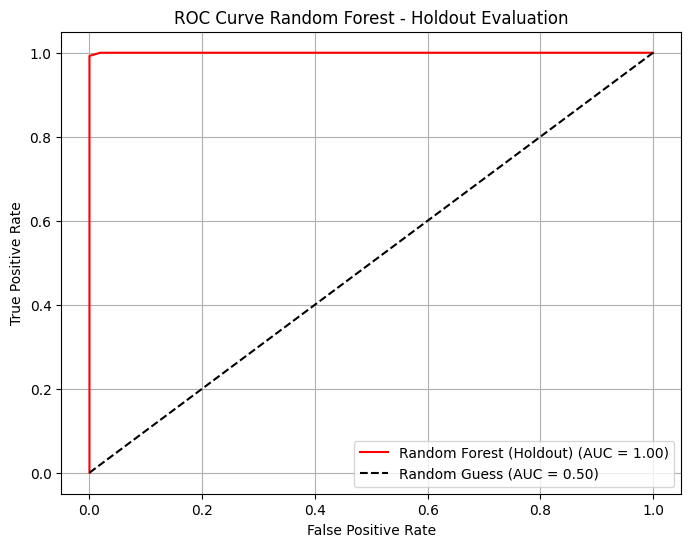

In [ ]:
# === Holdout Evaluation ===
# y_test is already binary, no need for label_binarize

# Random Forest (Holdout) ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

# === Plotting ROC untuk Random Forest (Holdout) ===
plt.figure(figsize=(8, 6))

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (Holdout) (AUC = {roc_auc_rf:.2f})', linestyle='-', color='red')

# Menambahkan garis diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

# Menambahkan label dan judul
plt.title('ROC Curve Random Forest - Holdout Evaluation')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# **KNN**

In [ ]:
# Inisialisasi model KNN
knn_model = KNeighborsClassifier()

# Training dan prediksi untuk KNN
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluasi untuk KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, knn_model.predict_proba(X_test_scaled)[:, 1])

# Hasil evaluasi
print("\n=== K-Nearest Neighbors (Holdout) ===")
print(f"Akurasi: {accuracy_knn:.2f}")
print(f"Sensitivitas: {cm_knn[1, 1] / (cm_knn[1, 1] + cm_knn[1, 0]):.2f}")
print(f"Spesifisitas: {cm_knn[0, 0] / (cm_knn[0, 0] + cm_knn[0, 1]):.2f}")
print(f"AUC: {roc_auc_knn:.2f}")


=== K-Nearest Neighbors (Holdout) ===
Akurasi: 1.00
Sensitivitas: 0.99
Spesifisitas: 1.00
AUC: 1.00


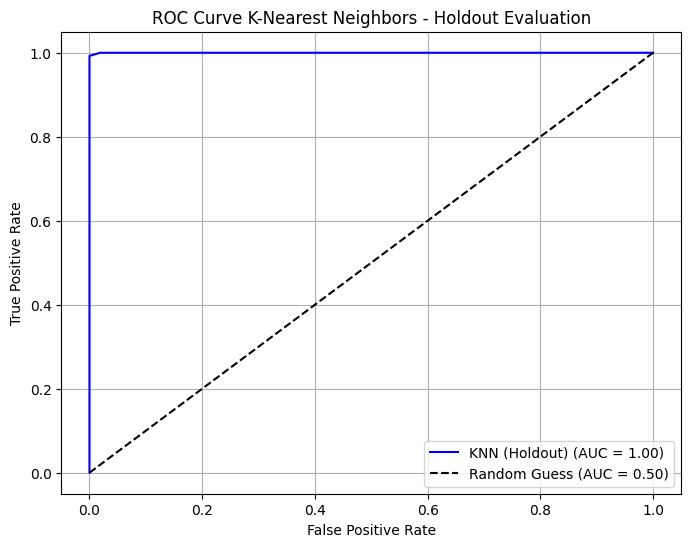

In [ ]:
# KNN (Holdout) ROC Curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_model.predict_proba(X_test_scaled)[:, 1])
roc_auc_knn = auc(fpr_knn, tpr_knn)

# === Plotting ROC untuk KNN (Holdout) ===
plt.figure(figsize=(8, 6))

plt.plot(fpr_knn, tpr_knn, label=f'KNN (Holdout) (AUC = {roc_auc_knn:.2f})', linestyle='-', color='blue')

# Menambahkan garis diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

# Menambahkan label dan judul
plt.title('ROC Curve K-Nearest Neighbors - Holdout Evaluation')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# **RANDOM FOREST (K-FOLD CV)**

In [ ]:
# Inisialisasi model Random Forest
rf_model_cv = RandomForestClassifier(random_state=42)

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)

# Evaluasi model menggunakan cross_val_score untuk berbagai metrik
scoring = ['accuracy', 'precision', 'recall', 'f1']
results_cv = {}

for metric in scoring:
    scores = cross_val_score(rf_model_cv, X_rfe_logreg, y_onehot, scoring=metric, cv=cv, n_jobs=-1)
    results_cv[metric] = scores

# Cetak hasil evaluasi
print("\n=== Random Forest (K-Fold Cross-Validation) ===")
for metric, scores in results_cv.items():
    print(f"{metric.capitalize()}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")



=== Random Forest (K-Fold Cross-Validation) ===
Accuracy: 0.9970 (+/- 0.0018)
Precision: 1.0000 (+/- 0.0000)
Recall: 0.9939 (+/- 0.0038)
F1: 0.9969 (+/- 0.0019)


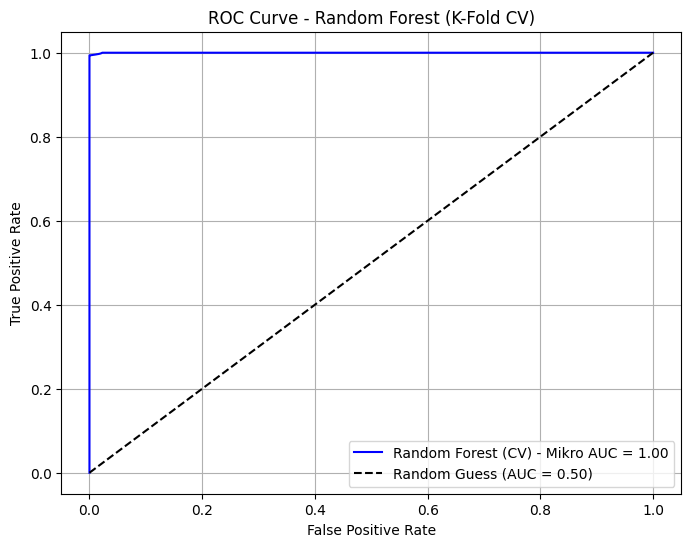

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# === Plot ROC untuk Random Forest (K-Fold CV) ===
plt.figure(figsize=(8, 6))

# Plot ROC untuk Random Forest (K-Fold CV) dengan Mikro AUC
plt.plot(fpr_rf_cv, tpr_rf_cv, label=f'Random Forest (CV) - Mikro AUC = {roc_auc_rf_cv:.2f}', linestyle='-', color='blue')

# Menambahkan garis diagonal (untuk acuan, model acak)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

# Menambahkan label dan judul
plt.title('ROC Curve - Random Forest (K-Fold CV)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)

# Menampilkan plot Random Forest
plt.show()

# **KNN (K-FOLD CV)**

In [ ]:
# Inisialisasi model KNN
knn_model_cv = KNeighborsClassifier()

# Definisikan strategi K-Fold Cross-Validation
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)

# Evaluasi model menggunakan cross_val_score untuk berbagai metrik
scoring = ['accuracy', 'precision', 'recall', 'f1']
results_cv_knn = {}

for metric in scoring:
    scores = cross_val_score(knn_model_cv, X_rfe_logreg, y_onehot, scoring=metric, cv=cv, n_jobs=-1)
    results_cv_knn[metric] = scores

# Cetak hasil evaluasi
print("\n=== K-Nearest Neighbors (K-Fold Cross-Validation) ===")
for metric, scores in results_cv_knn.items():
    print(f"{metric.capitalize()}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")


=== K-Nearest Neighbors (K-Fold Cross-Validation) ===
Accuracy: 0.9970 (+/- 0.0018)
Precision: 1.0000 (+/- 0.0000)
Recall: 0.9939 (+/- 0.0038)
F1: 0.9969 (+/- 0.0019)


K-Nearest Neighbors (K-Fold CV) - Micro-average AUC: 1.00


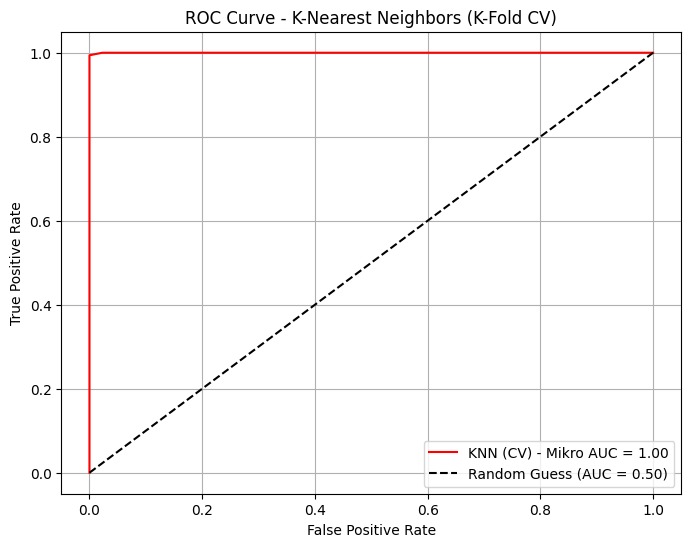

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Hitung ROC Curve untuk K-Nearest Neighbors (K-Fold CV)

# Buat kembali RepeatedStratifiedKFold untuk iterasi
cv_roc_knn = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)

# Inisialisasi model K-Nearest Neighbors
knn_model_cv_single = KNeighborsClassifier()

# Gabungkan semua y_true dan y_score dari semua fold untuk micro-average
y_true_concat_knn = np.array([])
y_score_concat_knn = np.array([])

# Iterasi melalui setiap fold
for i, (train_index, test_index) in enumerate(cv_roc_knn.split(X_rfe_logreg, y_onehot)):
    X_train_cv, X_test_cv = X_rfe_logreg[train_index], X_rfe_logreg[test_index]
    y_train_cv, y_test_cv = y_onehot.iloc[train_index], y_onehot.iloc[test_index]

    # Scaling data dalam setiap fold (penting untuk menghindari data leakage)
    scaler_cv_knn = StandardScaler()
    X_train_cv_scaled = scaler_cv_knn.fit_transform(X_train_cv)
    X_test_cv_scaled = scaler_cv_knn.transform(X_test_cv)

    # Latih model K-Nearest Neighbors
    knn_model_cv_single.fit(X_train_cv_scaled, y_train_cv)

    # Dapatkan probabilitas prediksi untuk kelas positif
    y_pred_proba_cv_knn = knn_model_cv_single.predict_proba(X_test_cv_scaled)[:, 1]

    # Kumpulkan y_true dan y_score untuk micro-average
    y_true_concat_knn = np.concatenate((y_true_concat_knn, y_test_cv))
    y_score_concat_knn = np.concatenate((y_score_concat_knn, y_pred_proba_cv_knn))

# Hitung micro-average ROC curve
fpr_knn_cv, tpr_knn_cv, _ = roc_curve(y_true_concat_knn, y_score_concat_knn)
roc_auc_knn_cv = auc(fpr_knn_cv, tpr_knn_cv)

print(f"K-Nearest Neighbors (K-Fold CV) - Micro-average AUC: {roc_auc_knn_cv:.2f}")

# === Plot ROC untuk K-Nearest Neighbors (K-Fold CV) ===
plt.figure(figsize=(8, 6))

# Plot ROC untuk K-Nearest Neighbors (K-Fold CV) dengan Mikro AUC
plt.plot(fpr_knn_cv, tpr_knn_cv, label=f'KNN (CV) - Mikro AUC = {roc_auc_knn_cv:.2f}', linestyle='-', color='red')

# Menambahkan garis diagonal (untuk acuan, model acak)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

# Menambahkan label dan judul
plt.title('ROC Curve - K-Nearest Neighbors (K-Fold CV)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)

# Menampilkan plot K-Nearest Neighbors
plt.show()